In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv


In [2]:
data = pd.read_csv('/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv')
data.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [3]:
data.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [4]:
data.drop(['Unnamed: 0'], axis=1)

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler

In [6]:
#Convert in 2D array
X = data['YearsExperience'].values.reshape(-1, 1)
y = data['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=42)

#Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training the model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [7]:
print("Linear Regression:")
print("  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("  R²:", r2_score(y_test, y_pred_lr))

Linear Regression:
  RMSE: 6229.172416338351
  R²: 0.9347210011126783


In [8]:
import xgboost as xgb
#From linear regression to  XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [9]:
print("XGBoost:")
print("  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("  R²:", r2_score(y_test, y_pred_xgb))

XGBoost:
  RMSE: 9455.187680848567
  R²: 0.8495981807546069


While not perfect. We can observe a significant worsening of the prediction accuracy: the RMSE was increased by 32% and the R² went from 0.94 to almost 0.84.

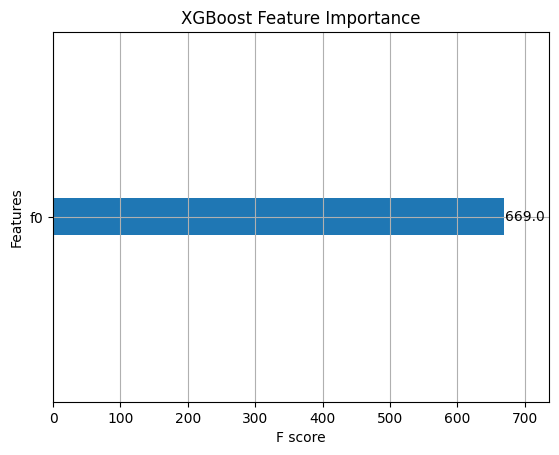

In [10]:
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance")
plt.show()